In [3]:
import pandas as pd
import numpy as np


In [4]:
df=pd.read_csv('data/heart_diceases.csv')

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

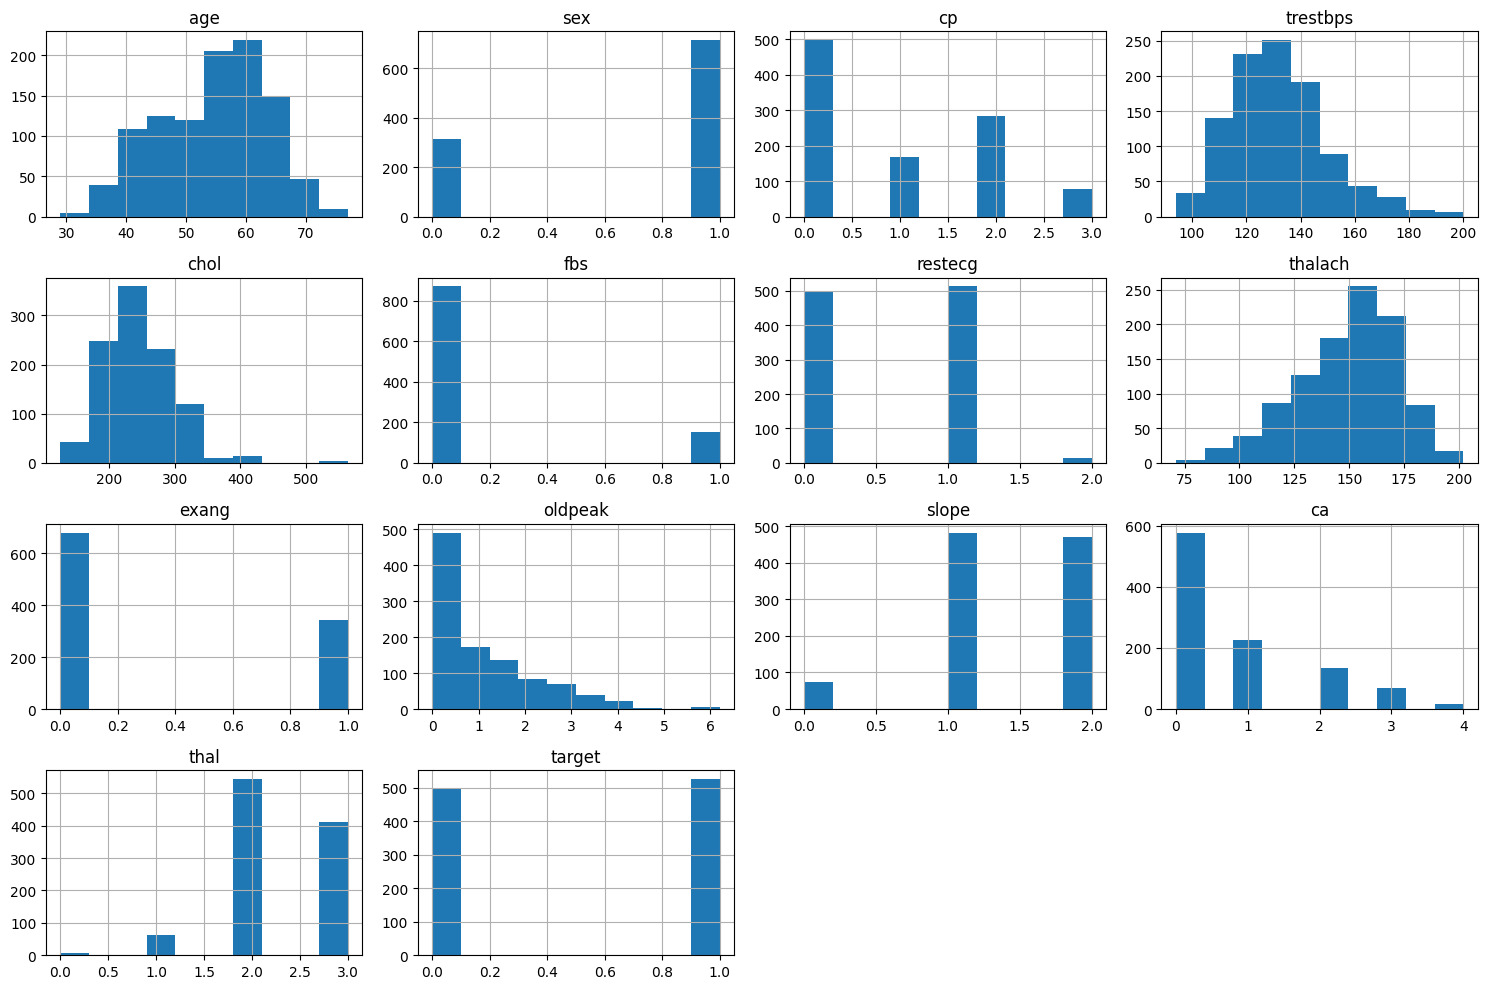

In [7]:
import matplotlib.pyplot as plt
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

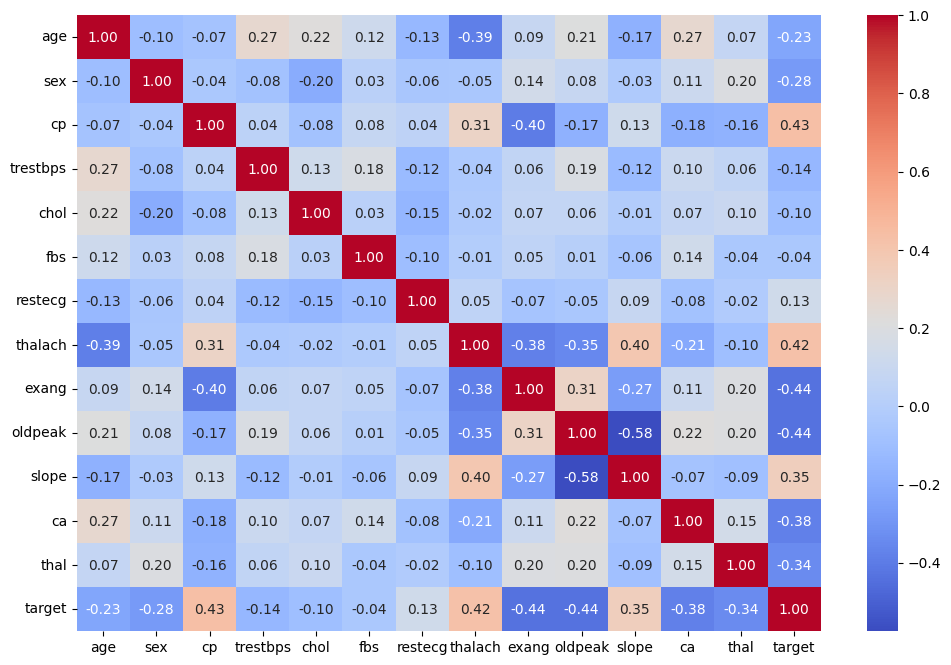

In [8]:
import seaborn as sns
corr=df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [9]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [10]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [11]:
categorical_cols=['cp', 'slope', 'thal']
df=pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

In [12]:
df

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,1,168,0,1.0,2,0,0,0,0,0,1,0,0,1
1,53,1,140,203,1,0,155,1,3.1,0,0,0,0,0,0,0,0,0,1
2,70,1,145,174,0,1,125,1,2.6,0,0,0,0,0,0,0,0,0,1
3,61,1,148,203,0,1,161,0,0.0,1,0,0,0,0,0,1,0,0,1
4,62,0,138,294,1,1,106,0,1.9,3,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,140,221,0,1,164,1,0.0,0,1,1,0,0,0,1,0,1,0
1021,60,1,125,258,0,0,141,1,2.8,1,0,0,0,0,1,0,0,0,1
1022,47,1,110,275,0,0,118,1,1.0,1,0,0,0,0,1,0,0,1,0
1023,50,0,110,254,0,0,159,0,0.0,0,1,0,0,0,0,1,0,1,0


In [13]:
numeric_cols=['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler=StandardScaler()
x=df.drop('target', axis=1)
y=df['target']
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)
x_train[numeric_cols]=scaler.fit_transform(x_train[numeric_cols])
x_test[numeric_cols]=scaler.transform(x_test[numeric_cols])
x_train


,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,cp_1,cp_2,cp_3,slope_1,slope_2,thal_1,thal_2,thal_3
835,-0.585840,1,-0.779454,-1.935031,0,0,-1.019094,0,-0.210661,3,0,1,0,0,1,0,1,0
137,1.051477,0,2.741732,1.610634,0,1,0.202882,1,-0.912152,0,0,0,0,0,1,0,1,0
534,-0.040068,0,-1.347387,0.442176,0,0,0.770228,0,-0.912152,0,0,1,0,0,1,0,1,0
495,0.505705,1,0.186033,-0.222636,0,1,0.508376,0,-0.473720,0,0,0,0,1,0,0,0,1
244,-0.367531,1,-0.381900,-0.001032,1,0,0.726586,0,1.192321,0,0,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,-1.459076,1,-0.097934,-0.625552,0,0,0.813870,0,0.841576,0,0,1,0,1,0,0,1,0
71,0.724014,1,0.469999,-0.766573,0,0,-0.495390,1,0.753889,1,0,0,0,0,1,0,0,1
106,-0.367531,1,0.469999,1.086843,0,1,1.032080,1,0.490830,0,0,0,0,0,1,0,0,1
270,-1.240767,1,-1.233800,-0.685990,0,1,0.508376,0,-0.912152,0,0,0,0,0,1,0,0,1


In [14]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression(solver='liblinear', penalty='l2', max_iter=1000)
log_reg.fit(x_train, y_train)
y_pred=log_reg.predict(x_test)



C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
acc_score=accuracy_score(y_test, y_pred)
prec_score=precision_score(y_test, y_pred)
rec_score=recall_score(y_test, y_pred)
f1=f1_score(y_test, y_pred)
cm=confusion_matrix(y_test, y_pred)
acc_score, prec_score, rec_score, f1, cm

(0.8195121951219512,
 0.7796610169491526,
 0.8932038834951457,
 0.832579185520362,
 array([[76, 26],
        [11, 92]]))

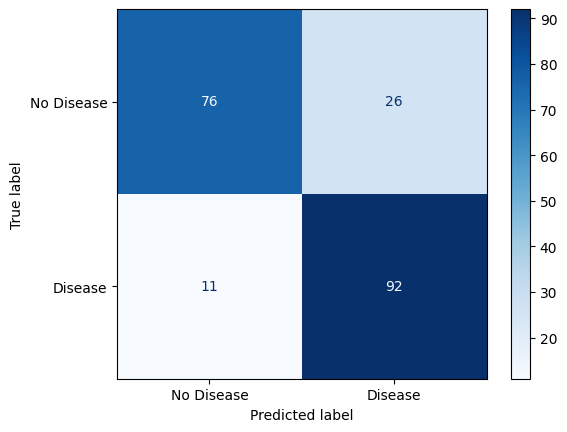

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease']).plot(cmap=plt.cm.Blues)
plt.show()